---
# Part 1 · Colab, and the four things Python can do  ⏱ 10 min

## The interface

You are looking at a **notebook**: a stack of **cells**. Each cell is either **text** (like this one) or **code** (grey background, ▶ button on the left).

| Action | How |
|---|---|
| Run this cell, move to the next | `Shift + Enter` |
| Run this cell, stay here | `Ctrl/Cmd + Enter` |
| New code cell below | `Ctrl/Cmd + M` then `B`, or the **+ Code** button |
| See what a function does | Type `pd.read_csv(` then `Shift + Tab` |
| Autocomplete a name | Start typing, press `Tab` |
| Everything is broken | **Runtime → Restart session**, then re-run from the top |

**Nothing you do here can break your computer.** Colab runs on a Google machine that is thrown away when you close the tab. Experiment freely.

> ⚠️ **Save your work:** File → Save a copy in Drive. Otherwise your edits vanish with the tab.

---

## Everything in Python is one of four things

1. **A value** — a number, a piece of text, True/False
2. **A container** — a list or a dictionary holding many values
3. **A function** — a verb: it takes something in, gives something back
4. **An object** — a thing that carries its own functions around with it (`df.mean()`)

That is genuinely the whole language. Run the next four cells.

In [1]:
# ── 1. VALUES ────────────────────────────────────────────────
species   = "Gentoo"      # str    text, in quotes
flipper   = 217           # int    whole number
mass_kg   = 5.05          # float  decimal
is_adult  = True          # bool   True or False

print(species, flipper, mass_kg, is_adult)

# type() tells you what kind of thing something is.
# When something misbehaves, this is your first question.
print(type(species), type(flipper), type(mass_kg), type(is_adult))

# Careful — quotes change everything:
print("217" + "3")     # text joined together
print(217 + 3)         # numbers added

Gentoo 217 5.05 True
<class 'str'> <class 'int'> <class 'float'> <class 'bool'>
2173
220


In [2]:
# ── 2. CONTAINERS ────────────────────────────────────────────

# A LIST: ordered, counted from ZERO
flippers = [181, 186, 195, 217, 230]

print("First :", flippers[0])
print("Third :", flippers[2])
print("Last  :", flippers[-1])
print("Count :", len(flippers))
print("Slice :", flippers[1:3])     # from 1 UP TO BUT NOT INCLUDING 3

# A DICTIONARY: labelled, looked up by name — like one row of a spreadsheet
penguin = {"species": "Gentoo", "flipper_mm": 217, "mass_g": 5050}

print("\nSpecies:", penguin["species"])
print("All labels:", list(penguin.keys()))

First : 181
Third : 195
Last  : 230
Count : 5
Slice : [186, 195]

Species: Gentoo
All labels: ['species', 'flipper_mm', 'mass_g']


In [3]:
# ── 3. FUNCTIONS ─────────────────────────────────────────────
# A function is a verb you can reuse. Define once, call forever.

def mass_in_kg(grams):
    '''Convert body mass from grams to kilograms.'''
    return grams / 1000

print(mass_in_kg(5050), "kg")
print(mass_in_kg(3700), "kg")

# Built-in functions you will use constantly:
print("\nlen  :", len(flippers))
print("sum  :", sum(flippers))
print("max  :", max(flippers))
print("round:", round(sum(flippers) / len(flippers), 1))

5.05 kg
3.7 kg

len  : 5
sum  : 1009
max  : 230
round: 201.8


In [4]:
# ── 4. OBJECTS ───────────────────────────────────────────────
# An object carries its own functions ("methods"), reached with a dot.

name = "gentoo penguin"

print(name.upper())            # SHOUT
print(name.title())            # Title Case
print(name.replace("penguin", "🐧"))
print(name.split(" "))         # → a list

# Type a dot after a variable and press Tab in Colab to see every method available.

GENTOO PENGUIN
Gentoo Penguin
gentoo 🐧
['gentoo', 'penguin']


## A DataFrame is just a dictionary of lists

Before we load 344 penguins, build three by hand. This demystifies what pandas actually is.

In [5]:
import pandas as pd

mini = pd.DataFrame({
    "species"    : ["Adelie", "Chinstrap", "Gentoo"],
    "flipper_mm" : [190, 196, 216],
    "mass_g"     : [3700, 3700, 5050],
})

display(mini)

print("\nOne column (a Series):")
print(mini["flipper_mm"])

print("\nOne row:", mini.loc[2, "species"])
print("Mean flipper:", mini["flipper_mm"].mean())

# Make a new column from existing ones — the whole column at once, no loop needed
mini["mass_kg"] = mini["mass_g"] / 1000
display(mini)

,species,flipper_mm,mass_g
0,Adelie,190,3700
1,Chinstrap,196,3700
2,Gentoo,216,5050



One column (a Series):
0    190
1    196
2    216
Name: flipper_mm, dtype: int64

One row: Gentoo
Mean flipper: 200.66666666666666


,species,flipper_mm,mass_g,mass_kg
0,Adelie,190,3700,3.70
1,Chinstrap,196,3700,3.70
2,Gentoo,216,5050,5.05


---
# Part 2 · The analysis  ⏱ 20 min

## 2.1 Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, linregress, pearsonr, mannwhitneyu, kruskal

plt.rcParams.update({
    "font.size"        : 11,
    "axes.linewidth"   : 0.9,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "figure.dpi"       : 110,
    "savefig.bbox"     : "tight",
    "savefig.dpi"      : 300,
})

# The official palmerpenguins colours — used in every paper and poster about this dataset
SPECIES = ["Adelie", "Chinstrap", "Gentoo"]
PAL     = {"Adelie": "#FF8C00", "Chinstrap": "#C65BCF", "Gentoo": "#067276"}

print("✅ Ready.")

✅ Ready.


## 2.2 Load

`pd.read_csv()` reads a spreadsheet straight from a web address. No download, no Excel, and **anyone who runs this notebook gets the identical data** — which is the whole point of doing it in code.

In [7]:
URL = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"

penguins = pd.read_csv(URL)

print("Shape (rows, columns):", penguins.shape)
penguins.head()

Shape (rows, columns): (344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 2.3 Explore — the four questions

Before plotting anything, ask the same four questions of every dataset you ever meet.

In [8]:
# Q1 — What is in here, and what type is each column?
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


In [9]:
# Q2 — Are the numbers plausible?
display(penguins.describe().round(1))

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.0,342.0,342.0,342.0,344.0
mean,43.9,17.2,200.9,4201.8,2008.0
std,5.5,2.0,14.1,802.0,0.8
min,32.1,13.1,172.0,2700.0,2007.0
25%,39.2,15.6,190.0,3550.0,2007.0
50%,44.4,17.3,197.0,4050.0,2008.0
75%,48.5,18.7,213.0,4750.0,2009.0
max,59.6,21.5,231.0,6300.0,2009.0


In [10]:
# Q3 — How is the data split between groups?
print("Penguins per species:")
print(penguins["species"].value_counts(), "\n")

print("Species × island:")
display(pd.crosstab(penguins["island"], penguins["species"]))

Penguins per species:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64 

Species × island:


species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


### 🔍 Stop and look at that table

**Chinstraps live only on Dream. Gentoos live only on Biscoe.** Only Adélies were sampled on all three islands.

Species and island are **confounded**: you cannot tell an island effect from a species effect, because they never vary independently. No amount of clever statistics fixes this — it is baked into how the data was collected.

Spotting this in the first five minutes is worth more than any figure you make afterwards.

In [11]:
# Q4 — What is missing?
print("Missing values per column:")
print(penguins.isna().sum().to_string())

print("\nThe incomplete rows:")
display(penguins[penguins.isna().any(axis=1)])

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0

The incomplete rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,2007
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009


### 🔍 Two different kinds of missing

- **2 rows** are missing *every* measurement — those birds were seen but never measured.
- **9 more rows** are missing only `sex` — the bird was measured, but its sex could not be determined in the field.

Deleting all 11 rows costs you 9 complete sets of measurements. Whether that matters depends on your question, so **be explicit about it** rather than letting `dropna()` decide silently.

Today we compare males and females, so we drop all 11 — and we say so.

In [12]:
df = penguins.dropna().reset_index(drop=True)

print(f"Started with {len(penguins)} penguins")
print(f"Dropped     {len(penguins) - len(df)} incomplete records")
print(f"Analysing   {len(df)} penguins\n")

display(df.groupby("species")[["bill_length_mm", "bill_depth_mm",
                               "flipper_length_mm", "body_mass_g"]].median().round(1))

Started with 344 penguins
Dropped     11 incomplete records
Analysing   333 penguins



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.8,18.4,190.0,3700.0
Chinstrap,49.6,18.4,196.0,3700.0
Gentoo,47.4,15.0,216.0,5050.0


> **`groupby` is a PivotTable.** *Split* the table by species → *apply* `median()` to each piece → *combine* the answers into a new table.
>
> Already something jumps out: Adélie and Chinstrap have almost identical bill **depth** (18.4 vs 18.5 mm) but wildly different bill **length** (38.9 vs 49.6 mm). Remember that.

## 2.4 Figure 1 — Ridgeline plot

Three overlapping density curves, one per species. Sometimes called a **joyplot**.

A density curve is a smoothed histogram: **height = how many penguins have that value**. Stacking them with a slight overlap makes group differences obvious in a way three separate histograms never do.

We build this one from scratch with `fill_between`, so you can see that a "fancy" plot is just simple shapes stacked on separate axes.

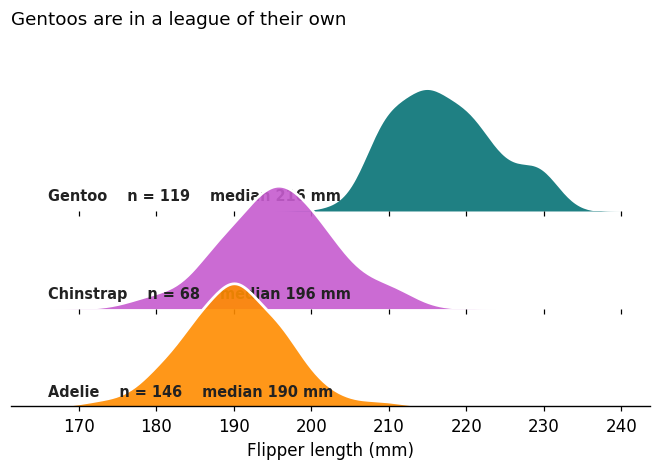

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(7.5, 4.4), sharex=True)
fig.subplots_adjust(hspace=-0.45)          # negative gap = the curves overlap

x_grid = np.linspace(165, 240, 300)

for ax, sp in zip(axes, SPECIES[::-1]):    # reversed so Adelie ends up in front
    values  = df.loc[df["species"] == sp, "flipper_length_mm"]
    density = gaussian_kde(values)(x_grid)
    density = density / density.max()       # equal heights, so shape is comparable

    ax.fill_between(x_grid, density, color=PAL[sp], alpha=0.9, lw=0)
    ax.plot(x_grid, density, color="white", lw=1.8)
    ax.text(166, 0.06, f"{sp}    n = {len(values)}    median {values.median():.0f} mm",
            fontsize=9.5, fontweight="bold", color="#222", va="bottom")

    ax.set_ylim(0, 1.45)
    ax.set_yticks([])
    ax.patch.set_alpha(0)                   # transparent, so curves show through
    for side in ["left", "right", "top", "bottom"]:
        ax.spines[side].set_visible(False)

axes[-1].spines["bottom"].set_visible(True)
axes[-1].set_xlabel("Flipper length (mm)")
axes[0].set_title("Gentoos are in a league of their own", loc="left", fontsize=12)
plt.show()

> **Reading it:** Adélie and Chinstrap overlap almost completely (medians 190 and 196 mm). Gentoo barely touches either (216 mm).
>
> **So flipper length alone separates Gentoo from the rest, and is useless for telling Adélie from Chinstrap.** One measurement is rarely enough — which is exactly why we go 2-dimensional next.
>
> Kruskal–Wallis across the three species: H = 237, p ≈ 3 × 10⁻⁵².

## 2.5 Figure 2 — The bubble scatter, and a famous trap

Now two measurements at once: **bill length** on x, **bill depth** on y, and we let the **size of each bubble** encode a third variable, body mass.

We fit a straight line through all 333 penguins, and a separate line through each species. Look carefully at what they do.

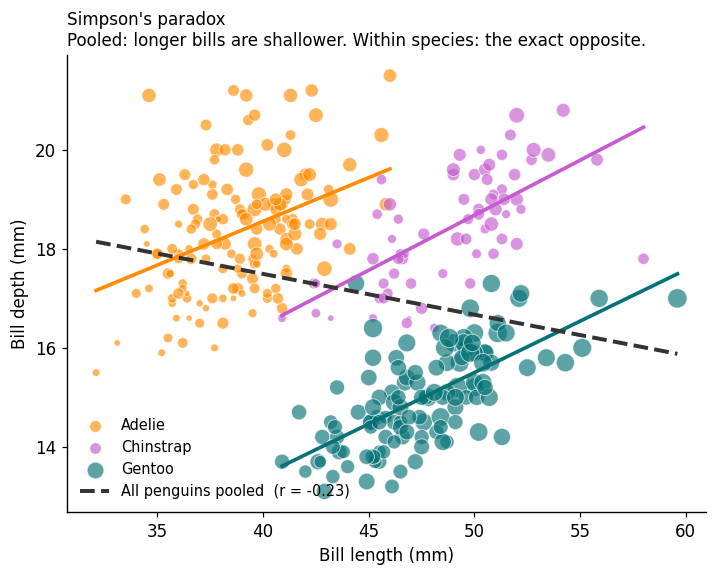

Adelie     n = 146   r = +0.39   p = 1.5e-06
Chinstrap  n =  68   r = +0.65   p = 1.5e-09
Gentoo     n = 119   r = +0.65   p = 7.3e-16
POOLED     n = 333   r = -0.23   p = 2.5e-05


In [14]:
fig, ax = plt.subplots(figsize=(7.5, 5.4))

for sp in SPECIES:
    sub = df[df["species"] == sp]
    ax.scatter(sub["bill_length_mm"], sub["bill_depth_mm"],
               s=(sub["body_mass_g"] - 2500) / 22,      # bubble area ∝ body mass
               color=PAL[sp], alpha=0.65, edgecolor="white", linewidth=0.6,
               label=sp, zorder=3)

    fit  = linregress(sub["bill_length_mm"], sub["bill_depth_mm"])
    xs   = np.linspace(sub["bill_length_mm"].min(), sub["bill_length_mm"].max(), 50)
    ax.plot(xs, fit.intercept + fit.slope * xs, color=PAL[sp], lw=2.4, zorder=4)

# One line through everything, ignoring species
allfit = linregress(df["bill_length_mm"], df["bill_depth_mm"])
xs     = np.linspace(df["bill_length_mm"].min(), df["bill_length_mm"].max(), 50)
ax.plot(xs, allfit.intercept + allfit.slope * xs, color="#333", lw=2.6, ls="--", zorder=5,
        label=f"All penguins pooled  (r = {allfit.rvalue:.2f})")

ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
ax.set_title("Simpson's paradox\nPooled: longer bills are shallower. Within species: the exact opposite.",
             loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9.5, loc="lower left")
plt.show()

for sp in SPECIES:
    sub = df[df["species"] == sp]
    r, p = pearsonr(sub["bill_length_mm"], sub["bill_depth_mm"])
    print(f"{sp:10s} n = {len(sub):3d}   r = {r:+.2f}   p = {p:.1e}")
r, p = pearsonr(df["bill_length_mm"], df["bill_depth_mm"])
print(f"{'POOLED':10s} n = {len(df):3d}   r = {r:+.2f}   p = {p:.1e}")

> ### This is Simpson's paradox, and it is not a curiosity
>
> Pooled across all penguins: **r = −0.23**. Longer bills look *shallower*.
> Within each species: **r = +0.39, +0.65, +0.65**. Longer bills are *deeper*.
>
> **Same data. Opposite conclusion.** The pooled line is an artefact of Gentoos having long, shallow bills and sitting in the bottom-right corner — a *between-species* difference masquerading as a *within-species* trend.
>
> **The lesson for your own work:** if your samples come from distinguishable groups — cell lines, patients, batches, plates, timepoints — a single pooled regression can point the wrong way. Plot the groups separately before you trust any correlation.
>
> Notice too that the *two-dimensional* view separates all three species cleanly, where flipper length alone could not. And the bubbles show Gentoos are the heaviest by a wide margin.

## 2.6 Figure 3 — Joint plot: the scatter with its own margins

`sns.jointplot` draws a scatter **and** the distribution of each axis in the margins — three plots in one line of code.

Use it when you want to show a relationship *and* prove the groups are genuinely separated on each axis.

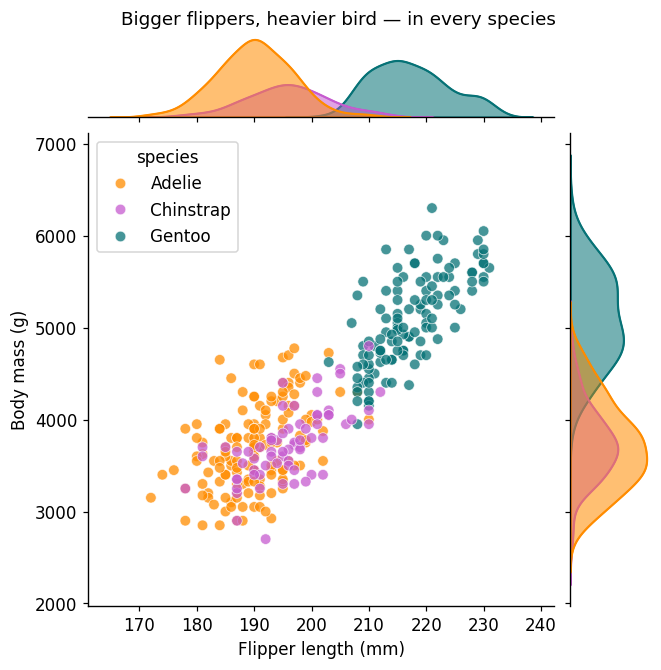

Overall: 50 g of body mass per extra mm of flipper (r = 0.87, p = 3.1e-105)
Saved → penguins_flipper_mass.png


In [15]:
g = sns.jointplot(data=df, x="flipper_length_mm", y="body_mass_g",
                  hue="species", hue_order=SPECIES, palette=PAL,
                  height=6, s=48, alpha=0.75, edgecolor="white", linewidth=0.5)

g.plot_marginals(sns.kdeplot, fill=True, alpha=0.4, lw=1.4)

g.set_axis_labels("Flipper length (mm)", "Body mass (g)")
g.figure.suptitle("Bigger flippers, heavier bird — in every species", y=1.01, fontsize=12)
plt.show()

fit = linregress(df["flipper_length_mm"], df["body_mass_g"])
print(f"Overall: {fit.slope:.0f} g of body mass per extra mm of flipper "
      f"(r = {fit.rvalue:.2f}, p = {fit.pvalue:.1e})")

# Save it at print resolution — look in the Files 📁 panel on the left to download
g.savefig("penguins_flipper_mass.png", dpi=300)
print("Saved → penguins_flipper_mass.png")

> **Reading it:** the marginal curve along the top is the ridgeline plot from Figure 1, lying on its side. The curve on the right shows body mass — Gentoos are cleanly separated there too.
>
> Here the relationship holds up: flipper length and body mass rise together **both** pooled and within each species. That is what a trustworthy correlation looks like, and it is worth contrasting with Figure 2.

---
# Part 3 · 🚪 Breakout rooms  ⏱ 15 min

Four challenges, roughly in order of difficulty. **Get through what you get through** — nobody finishes all four.

One person shares their screen; everyone else reads the error messages out loud. Solutions are at the bottom of the notebook.

**Reminders:**
- Column names: `species`, `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`, `sex`, `year`
- The cleaned table is called `df` (333 penguins)

### 🎯 Challenge 1 — Split violins: do males and females differ?

A **split violin** puts two groups back-to-back in one shape, so you compare them without doubling the width of your figure.

Fill in the three blanks. `hue` is the variable that splits each violin; `split=True` glues the halves together.

ValueError: Could not interpret value `____` for `y`. An entry with this name does not appear in `data`.

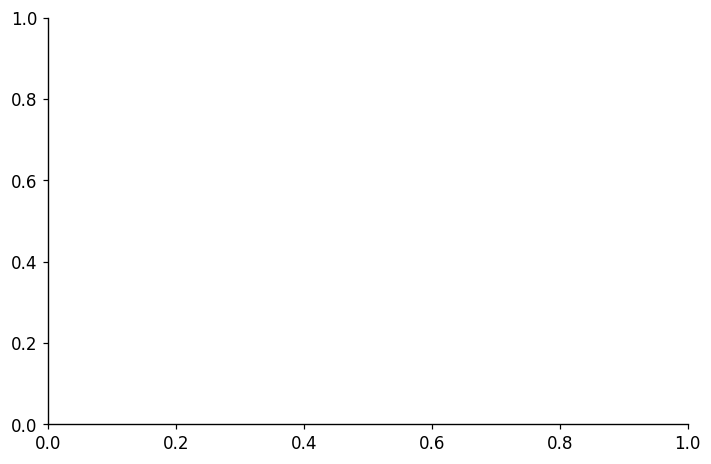

In [16]:
# 🎯 YOUR TURN — replace each ____
fig, ax = plt.subplots(figsize=(7.5, 4.8))

sns.violinplot(data=df, x="species", y="____", order=SPECIES,
               hue="____", split=True, inner="quart", cut=0,
               palette={"female": "#f4a261", "male": "#2a6f97"}, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Body mass (g)")
ax.set_title("____", loc="left", fontsize=11)
ax.legend(title="Sex", frameon=False)
plt.show()

display(df.groupby(["species", "sex"])["body_mass_g"].agg(["count", "median"]))

### 🎯 Challenge 2 — Put a number on it

The figure shows male Gentoos look heavier. **Is that difference bigger than chance?**

Use a **Mann–Whitney U test** — the non-parametric two-group comparison. It asks: if you pick one male and one female at random, how often is the male heavier?

Fill in the blanks.

In [ ]:
# 🎯 YOUR TURN — replace each ____
gentoo = df[df["species"] == "Gentoo"]

males   = gentoo.loc[gentoo["sex"] == "male",   "body_mass_g"]
females = gentoo.loc[gentoo["sex"] == "____", "body_mass_g"]

U, p = mannwhitneyu(males, females)

print(f"Male   n = {len(males):3d}   median {males.median():.0f} g")
print(f"Female n = {len(females):3d}   median {females.median():.0f} g")
print(f"\nMann–Whitney U = {U:.0f},  p = {p:.2e}")
print("Difference in medians:", males.median() - females.median(), "g")

# Now repeat it for Adelie and Chinstrap. Does the pattern hold?

### 🎯 Challenge 3 — Where do the penguins live?

Turn the species × island crosstab from section 2.3 into a **stacked bar chart**, so the confounded sampling is visible at a glance rather than buried in a table.

`pd.crosstab(...)` makes the table; `.plot(kind="bar", stacked=True)` draws it.

In [ ]:
# 🎯 YOUR TURN
counts = pd.crosstab(df["island"], df["species"])[SPECIES]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
counts.plot(kind="bar", stacked=True, ax=ax,
            color=[PAL[s] for s in SPECIES], edgecolor="white", linewidth=1.2)

ax.set_xlabel("")
ax.set_ylabel("Number of penguins")
ax.set_title("Two of three species were sampled on one island only", loc="left", fontsize=11)
ax.legend(frameon=False, title="")
plt.xticks(rotation=0)
plt.show()

# ❓ Question for your group:
# Gentoos are the heaviest species AND the only species on Biscoe.
# If someone told you "penguins on Biscoe are heavier", what would you say?

### 🎯 Challenge 4 — Everything against everything

`sns.pairplot` draws a scatter for **every pair** of numeric columns, with distributions down the diagonal. One line, sixteen panels.

It is the fastest way to survey a new dataset — always run it early.

**Your job:** run it, then write down which single pair of measurements separates all three species most cleanly.

In [ ]:
# 🎯 YOUR TURN — run it, then read it
MEASUREMENTS = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

g = sns.pairplot(df[MEASUREMENTS + ["species"]], hue="species",
                 hue_order=SPECIES, palette=PAL,
                 diag_kind="kde", plot_kws=dict(s=22, alpha=0.7, edgecolor="none"),
                 height=1.9)
g.figure.suptitle("Every measurement against every other", y=1.02, fontsize=12)
plt.show()

### 🎯 Stretch — make it yours

Pick any of the figures above and change one thing:

- Swap `palette=PAL` for `palette="viridis"`, `"rocket"`, `"mako"` or `"Set2"`
- Colour by `sex` or `year` instead of `species`
- Change `y="body_mass_g"` to `y="bill_depth_mm"`
- Add `sns.stripplot(...)` on top of a violin to show every raw point
- Turn Challenge 1 into a **raincloud**: violin + slim box + jittered points

**There is no way to break anything.** Change it, run it, see what happens.

In [ ]:
# 🎯 YOUR PLAYGROUND

---
# Part 4 · Your data  ⏱ 15 min

## Get your spreadsheet into Colab

Run the cell, click **Choose Files**, pick a `.csv` or `.xlsx` from your computer.

In [ ]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
mydata   = pd.read_csv(filename) if filename.endswith(".csv") else pd.read_excel(filename)

print("Loaded", filename, "→", mydata.shape[0], "rows ×", mydata.shape[1], "columns")
mydata.head()

## The four questions, on your data

The same checklist we used in section 2.3. Run it on anything new, every time.

In [ ]:
d = mydata      # 🎯 change this if your table has a different name

print("1. SIZE:", d.shape[0], "rows ×", d.shape[1], "columns\n")

print("2. TYPES — anything 'object' that should be a number is a problem:")
print(d.dtypes.to_string())

print("\n3. MISSING VALUES:")
missing = d.isna().sum()
print(missing[missing > 0].to_string() if missing.any() else "   none 🎉")

print("\n4. GROUPS — check for near-duplicates like 'Control' vs 'control ':")
for c in d.select_dtypes(exclude="number").columns[:6]:
    print(f"   {c:22s} {d[c].nunique():3d} unique → {list(d[c].dropna().unique()[:6])}")

print("\n5. NUMERIC SANITY CHECK — look for impossible min/max values:")
display(d.describe().round(2))

## Your figure, in five lines

Fill in two column names and run. This is the whole recipe.

In [ ]:
# 🎯 YOUR TURN
GROUP   = "your_category_column"     # e.g. treatment, genotype, timepoint
MEASURE = "your_numeric_column"      # e.g. absorbance, concentration, yield

fig, ax = plt.subplots(figsize=(7.5, 4.8))
sns.violinplot(data=mydata, x=GROUP, y=MEASURE, hue=GROUP,
               palette="crest", legend=False, inner="quart", cut=0, ax=ax)
sns.stripplot(data=mydata, x=GROUP, y=MEASURE, color="#22223b",
              size=4, alpha=0.6, jitter=0.15, ax=ax)

ax.set_title(f"{MEASURE} by {GROUP}", loc="left", fontsize=11)
plt.show()

display(mydata.groupby(GROUP)[MEASURE].agg(["count", "median", "mean", "std"]).round(2))

---
## Which plot should I use?

| Your data | Plot | Code |
|---|---|---|
| One measurement, few groups | **Box + strip** | `sns.boxplot` + `sns.stripplot` |
| One measurement, want the shape | **Violin** | `sns.violinplot(inner="quart")` |
| One measurement, two subgroups | **Split violin** | `sns.violinplot(hue=…, split=True)` |
| One measurement, several groups, show everything | **Ridgeline** | `fill_between` on stacked axes |
| Two measurements | **Scatter** | `sns.scatterplot` or `ax.scatter` |
| Two measurements + distributions | **Joint plot** | `sns.jointplot` |
| Many measurements at once | **Pair plot** | `sns.pairplot` |
| Counts in categories | **Stacked bar** | `pd.crosstab(...).plot(kind="bar", stacked=True)` |

## Which test should I use?

| Comparison | Test | Code |
|---|---|---|
| 2 groups, skewed or small | Mann–Whitney U | `mannwhitneyu(a, b)` |
| 2 groups, roughly normal | t-test | `ttest_ind(a, b)` |
| 3+ groups, skewed | Kruskal–Wallis | `kruskal(a, b, c)` |
| 2 continuous variables | Pearson / Spearman | `pearsonr(x, y)` / `spearmanr(x, y)` |
| 2 categorical variables | Chi-square | `chi2_contingency(pd.crosstab(a, b))` |

> **Before any test:** plot the data. A p-value cannot tell you your groups were confounded, that one outlier is driving everything, or that Simpson's paradox has flipped your sign. A figure can.

---
## What you did today

- Loaded a real dataset from a URL, reproducibly
- Found a **confound** (species ↔ island) before making a single figure
- Made a deliberate, stated decision about 11 incomplete records
- Built a ridgeline, a bubble scatter, a joint plot, split violins, a stacked bar and a pair plot
- Caught **Simpson's paradox** — pooled r = −0.23, within-species r = +0.65
- Ran Mann–Whitney and Kruskal–Wallis tests
- Saved a 300 dpi figure

---
## Resources

| Link | Why |
|---|---|
| [seaborn gallery](https://seaborn.pydata.org/examples/index.html) | Find a plot you like, copy the code |
| [From Data to Viz](https://www.data-to-viz.com/) | Flowchart: which plot for which data |
| [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html) | Official quick start |
| [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/) | The dataset, its artwork and its story |
| [Gorman et al. 2014, PLoS ONE](https://doi.org/10.1371/journal.pone.0090081) | The original paper |
| [Simpson's paradox](https://en.wikipedia.org/wiki/Simpson%27s_paradox) | The trap from Figure 2 |
| [scipy.stats reference](https://docs.scipy.org/doc/scipy/reference/stats.html) | Every test, with examples |
| [Kaggle Datasets](https://www.kaggle.com/datasets) | Free data to practise on |

**Keep this notebook.** File → Save a copy in Drive. The five-line recipe in Part 4 works on any spreadsheet you own.

---
---
# 🔑 Breakout solutions

*Try them first.*

In [ ]:
# ── Challenge 1 ──  blanks: "body_mass_g", "sex", and any sensible title
fig, ax = plt.subplots(figsize=(7.5, 4.8))

sns.violinplot(data=df, x="species", y="body_mass_g", order=SPECIES,
               hue="sex", split=True, inner="quart", cut=0,
               palette={"female": "#f4a261", "male": "#2a6f97"}, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Body mass (g)")
ax.set_title("Males are heavier in all three species", loc="left", fontsize=11)
ax.legend(title="Sex", frameon=False)
plt.show()

display(df.groupby(["species", "sex"])["body_mass_g"].agg(["count", "median"]))

In [ ]:
# ── Challenge 2 ──  the blank is "female". Here it is for all three species.
for sp in SPECIES:
    sub     = df[df["species"] == sp]
    males   = sub.loc[sub["sex"] == "male",   "body_mass_g"]
    females = sub.loc[sub["sex"] == "female", "body_mass_g"]
    U, p    = mannwhitneyu(males, females)
    print(f"{sp:10s} male {males.median():5.0f} g  vs  female {females.median():5.0f} g  "
          f"| Δ = {males.median() - females.median():4.0f} g  |  U = {U:6.0f}, p = {p:.1e}")

> **Result:** males are heavier in all three species, every comparison highly significant (Gentoo: 5500 vs 4700 g, p ≈ 2 × 10⁻¹⁹).
>
> **The point worth making:** this is *sexual dimorphism*, and it also means that any analysis pooling both sexes carries a hidden source of variation. If you compared "Gentoo vs Adélie body mass" using samples that happened to be mostly male Gentoos and mostly female Adélies, you would overstate the difference. Same structural problem as Simpson's paradox in Figure 2.

In [ ]:
# ── Challenge 3 ──  the answer to the question in the comment
#
# "Penguins on Biscoe are heavier" is TRUE but MEANINGLESS as stated.
# Biscoe is heavier because Biscoe is where the Gentoos are — the island is
# a stand-in for the species, not a cause of anything.
#
# Show it: within Adelie, the only species sampled on all three islands,
# island makes almost no difference to body mass.
adelie = df[df["species"] == "Adelie"]
print("Adelie body mass by island:")
print(adelie.groupby("island")["body_mass_g"].agg(["count", "median"]).round(0))

H, p = kruskal(*[g.values for _, g in adelie.groupby("island")["body_mass_g"]])
print(f"\nKruskal-Wallis within Adelie only: H = {H:.2f}, p = {p:.2f}")
print("→ no island effect once you hold species constant.")

In [ ]:
# ── Challenge 4 ──  which pair separates the three species best?
#
# BILL LENGTH vs BILL DEPTH. In that panel the three clouds barely touch:
#   - Gentoo    : long  bill, shallow bill  (bottom right)
#   - Chinstrap : long  bill, deep    bill  (top right)
#   - Adelie    : short bill, deep    bill  (top left)
#
# No single measurement does this. Flipper length merges Adelie with Chinstrap;
# body mass merges them too. It takes two dimensions.
fig, ax = plt.subplots(figsize=(6.8, 5))
for sp in SPECIES:
    sub = df[df["species"] == sp]
    ax.scatter(sub["bill_length_mm"], sub["bill_depth_mm"], s=42, alpha=0.75,
               color=PAL[sp], edgecolor="white", linewidth=0.5, label=sp)
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
ax.set_title("Two measurements, three clean clusters", loc="left", fontsize=11)
ax.legend(frameon=False)
plt.show()